# Text Vectorization Techniques: One-Hot Encoding, Bag-of-Words and TF-IDF

This notebook follows the same overall teaching style as the mentor-provided
`Vectorization_techniques.ipynb`: introduce the text vectorization idea,
prepare a small text corpus, apply each technique, inspect the resulting
matrices, and compare the techniques.

### Techniques covered
1. One-Hot Encoding
2. Bag-of-Words (Count Vectorization)
3. TF-IDF

The dataset contains 20 small movie reviews with Positive/Negative sentiment labels.

## 1. Import Required Libraries

We use:
- **Pandas** for dataset handling
- **NumPy** for numerical operations
- **Scikit-learn** for One-Hot Encoding, Count Vectorization and TF-IDF
- **Matplotlib** for visualization

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

## 2. Load the Dataset

In [3]:
# Load the small movie-review dataset
df = pd.read_csv("movie_reviews_small.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20, 2)


,text,sentiment
0,The movie was amazing and entertaining,Positive
1,I really enjoyed this wonderful movie,Positive
2,The acting was excellent and the story was great,Positive
3,This film was fantastic and worth watching,Positive
4,I loved the characters and the story,Positive


## 3. Understand the Dataset

The dataset contains:
- `text`: the movie review
- `sentiment`: Positive or Negative label

In [4]:
print(df.info())
print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       20 non-null     object
 1   sentiment  20 non-null     object
dtypes: object(2)
memory usage: 448.0+ bytes
None

Sentiment distribution:
sentiment
Positive    10
Negative    10
Name: count, dtype: int64

Missing values:
text         0
sentiment    0
dtype: int64


## 4. Basic Text Preprocessing

For this demonstration, we use simple preprocessing:
- convert text to lowercase
- remove punctuation
- remove extra whitespace

We keep the preprocessing intentionally simple so that the effect of each
vectorization technique remains easy to understand.

In [5]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(preprocess_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,The movie was amazing and entertaining,the movie was amazing and entertaining
1,I really enjoyed this wonderful movie,i really enjoyed this wonderful movie
2,The acting was excellent and the story was great,the acting was excellent and the story was great
3,This film was fantastic and worth watching,this film was fantastic and worth watching
4,I loved the characters and the story,i loved the characters and the story


# 5. One-Hot Encoding

One-Hot Encoding represents each **unique word** using a binary vector.
For a vocabulary of `N` words, every word receives a vector of length `N`
with one `1` and all other values `0`.

Example:

`movie → [0, 1, 0, 0, ...]`

One-Hot Encoding is mainly useful for demonstrating categorical word
representation. It does not capture word frequency or semantic similarity.

In [6]:
# Create the vocabulary from the complete corpus
all_words = sorted(set(" ".join(df["clean_text"]).split()))

print("Vocabulary size:", len(all_words))
print("First 20 vocabulary words:", all_words[:20])

Vocabulary size: 55
First 20 vocabulary words: ['a', 'about', 'acting', 'amazing', 'an', 'and', 'awful', 'bad', 'boring', 'brilliant', 'characters', 'completely', 'confusing', 'definitely', 'disappointing', 'dull', 'enjoyable', 'enjoyed', 'entertaining', 'entire']


In [7]:
# One-Hot encode the vocabulary itself
one_hot_encoder = OneHotEncoder(sparse_output=False, dtype=int)
one_hot_matrix = one_hot_encoder.fit_transform(np.array(all_words).reshape(-1, 1))

one_hot_df = pd.DataFrame(
    one_hot_matrix,
    index=all_words,
    columns=[f"v{i}" for i in range(one_hot_matrix.shape[1])]
)

print("One-Hot matrix shape:", one_hot_matrix.shape)
one_hot_df.head(10)

One-Hot matrix shape: (55, 55)


,v0,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v45,v46,v47,v48,v49,v50,v51,v52,v53,v54
a,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
about,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
acting,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
amazing,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
an,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
and,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
awful,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
bad,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
boring,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
brilliant,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### One-Hot Encoding of a sentence

A sentence can be represented as a sequence of one-hot vectors for its
individual words. Therefore, unlike Bag-of-Words and TF-IDF, the representation
does not naturally collapse an entire document into one fixed-length frequency
vector.

In [8]:
example_words = df.loc[0, "clean_text"].split()

print("Sentence:", df.loc[0, "clean_text"])
print("\nOne-Hot vectors:")

for word in example_words:
    print(word, "->", one_hot_df.loc[word].values)

Sentence: the movie was amazing and entertaining

One-Hot vectors:
the -> [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
movie -> [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
was -> [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
amazing -> [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
and -> [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
entertaining -> [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


# 6. Bag-of-Words (Count Vectorization)

Bag-of-Words represents each document using the **number of times each
vocabulary word occurs** in that document.

It ignores word order and focuses on word frequency.

For example, if the vocabulary contains `movie`, `great`, and `boring`:

`"movie movie great"` → `[2, 1, 0]`

In [9]:
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(df["clean_text"])

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
)

print("Bag-of-Words matrix shape:", bow_matrix.shape)
bow_df.head()

Bag-of-Words matrix shape: (20, 53)


,about,acting,amazing,an,and,awful,bad,boring,brilliant,characters,...,the,this,time,was,waste,watching,with,wonderful,worth,would
0,0,0,1,0,1,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
2,0,1,0,0,1,0,0,0,0,0,...,2,0,0,2,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,1,0,1,0,1,0,0,1,0
4,0,0,0,0,1,0,0,0,0,1,...,2,0,0,0,0,0,0,0,0,0


In [10]:
# Inspect the vocabulary
print("Number of BoW features:", len(bow_vectorizer.get_feature_names_out()))
print("First 30 features:")
print(bow_vectorizer.get_feature_names_out()[:30])

# Show the first review's non-zero word counts
print("\nFirst review:")
print(df.loc[0, "clean_text"])

print("\nNon-zero Bag-of-Words values:")
print(bow_df.iloc[0][bow_df.iloc[0] > 0])

Number of BoW features: 53
First 30 features:
['about' 'acting' 'amazing' 'an' 'and' 'awful' 'bad' 'boring' 'brilliant'
 'characters' 'completely' 'confusing' 'definitely' 'disappointing' 'dull'
 'enjoyable' 'enjoyed' 'entertaining' 'entire' 'excellent' 'extremely'
 'fantastic' 'film' 'good' 'great' 'hated' 'interesting' 'it' 'loved'
 'movie']

First review:
the movie was amazing and entertaining

Non-zero Bag-of-Words values:
amazing         1
and             1
entertaining    1
movie           1
the             1
was             1
Name: 0, dtype: int64


# 7. TF-IDF

TF-IDF stands for **Term Frequency–Inverse Document Frequency**.

It gives more importance to words that are frequent in a particular document
but less common across the complete collection of documents.

The basic idea is:

- **TF (Term Frequency):** how often a word appears in a document.
- **IDF (Inverse Document Frequency):** how rare the word is across documents.
- **TF-IDF:** TF × IDF.

Therefore, common words receive relatively lower importance while distinctive
words can receive higher weights.

In [11]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)
tfidf_df.head()

TF-IDF matrix shape: (20, 53)


,about,acting,amazing,an,and,awful,bad,boring,brilliant,characters,...,the,this,time,was,waste,watching,with,wonderful,worth,would
0,0.0,0.00000,0.590012,0.0,0.260480,0.0,0.0,0.0,0.0,0.000000,...,0.289890,0.000000,0.0,0.260480,0.0,0.000000,0.0,0.000000,0.000000,0.0
1,0.0,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.319981,0.0,0.000000,0.0,0.000000,0.0,0.479694,0.000000,0.0
2,0.0,0.32085,0.000000,0.0,0.210728,0.0,0.0,0.0,0.0,0.000000,...,0.469041,0.000000,0.0,0.421456,0.0,0.000000,0.0,0.000000,0.000000,0.0
3,0.0,0.00000,0.000000,0.0,0.219803,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.291929,0.0,0.219803,0.0,0.497875,0.0,0.000000,0.497875,0.0
4,0.0,0.00000,0.000000,0.0,0.239956,0.0,0.0,0.0,0.0,0.477766,...,0.534098,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0


In [12]:
# Show the highest TF-IDF words in the first review
first_review_tfidf = tfidf_df.iloc[0].sort_values(ascending=False)

print("First review:")
print(df.loc[0, "clean_text"])

print("\nHighest TF-IDF weights:")
print(first_review_tfidf[first_review_tfidf > 0].head(10))

First review:
the movie was amazing and entertaining

Highest TF-IDF weights:
amazing         0.590012
entertaining    0.590012
movie           0.289890
the             0.289890
and             0.260480
was             0.260480
Name: 0, dtype: float64


# 8. Word2Vec and Continuous Bag-of-Words (CBOW)

So far, One-Hot Encoding, Bag-of-Words and TF-IDF are **sparse representations**.
They mainly represent words using identity, counts or importance.

**Word2Vec** is different. It learns a **dense vector representation for each word
from the surrounding context**.

Word2Vec has two main training strategies:

- **CBOW (Continuous Bag-of-Words):** predicts a target word from its surrounding context words.
- **Skip-gram:** predicts surrounding context words from a target word.

In this notebook we use **CBOW**, so `sg=0` in `gensim.models.Word2Vec`.

> **Important:** our dataset is intentionally small. Word2Vec normally needs a much
> larger corpus to learn reliable semantic relationships. Here it is being used to
> demonstrate the mechanics of CBOW/Word2Vec.

## 8.1 Prepare Text for Word2Vec

Word2Vec expects the text as a list of tokenized sentences.

For example:

`"the movie was amazing"`

becomes:

`["the", "movie", "was", "amazing"]`

In [ ]:
# Tokenize each cleaned review
tokenized_docs = [
    sentence.split()
    for sentence in df["clean_text"]
]

print("First tokenized review:")
print(tokenized_docs[0])

## 8.2 How CBOW Works

Suppose the sentence is:

`the movie was amazing and entertaining`

With a context window of 2, CBOW can use surrounding words to predict a
target word.

For example:

```text
Context words                 Target
the, movie, amazing, and  →    was
```

The model learns word vectors during this prediction task.

Unlike Bag-of-Words, Word2Vec does not simply count words. It learns vectors
based on **which words occur near each other**.

In [ ]:
# Install gensim if it is not already installed.
# Run this only if the import below gives ModuleNotFoundError:
# !pip install gensim

In [ ]:
from gensim.models import Word2Vec

# Word2Vec with CBOW
w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=50,   # size of each word embedding
    window=3,        # number of neighboring words used as context
    min_count=1,     # keep every word in this small dataset
    sg=0,             # 0 = CBOW, 1 = Skip-gram
    workers=1,
    seed=42
)

print("Word2Vec training completed.")
print("Vocabulary size:", len(w2v_model.wv.index_to_key))
print("First 20 vocabulary words:")
print(w2v_model.wv.index_to_key[:20])

## 8.3 Word2Vec Word Vectors

Each word now has a **dense 50-dimensional vector**.

For example, we can retrieve the vector for `movie`.

In [ ]:
word = "movie"

movie_vector = w2v_model.wv[word]

print("Word:", word)
print("Vector shape:", movie_vector.shape)
print("Word vector:")
print(movie_vector)

## 8.4 Word Similarity

One of the main advantages of Word2Vec is that we can compare word vectors.

`similarity()` returns a value based on the cosine similarity between two
word vectors.

Because our dataset is very small, these similarities should be treated as
a demonstration rather than reliable linguistic knowledge.

In [ ]:
word1 = "movie"
word2 = "film"

similarity = w2v_model.wv.similarity(word1, word2)

print(f"Cosine similarity between '{word1}' and '{word2}': {similarity:.4f}")

In [ ]:
# Find words that are closest to "movie" in the learned embedding space
print("Words most similar to 'movie':")
print(w2v_model.wv.most_similar("movie", topn=5))

## 8.5 Visualize Word2Vec Embeddings

The actual Word2Vec vectors have 50 dimensions. PCA reduces them to 2 dimensions
only for visualization.

This is similar to the PCA visualization used later for Bag-of-Words and TF-IDF.

In [ ]:
from sklearn.decomposition import PCA

words = w2v_model.wv.index_to_key
vectors = w2v_model.wv[words]

pca_w2v = PCA(n_components=2, random_state=42)
w2v_2d = pca_w2v.fit_transform(vectors)

plt.figure(figsize=(10, 8))
plt.scatter(w2v_2d[:, 0], w2v_2d[:, 1])

for word, (x, y) in zip(words, w2v_2d):
    plt.annotate(
        word,
        (x, y),
        fontsize=9,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.title("Word2Vec (CBOW) Word Embeddings - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## 8.6 Word2Vec vs CBOW

**Word2Vec** is the overall word-embedding technique/framework.

**CBOW** is one of the two main ways Word2Vec can be trained.

So they are not two completely separate vectorization algorithms:

```text
Word2Vec
├── CBOW      → context words predict target word
└── Skip-gram → target word predicts context words
```

In `gensim`:

```text
sg=0 → CBOW
sg=1 → Skip-gram
```

# 9. Direct Comparison of the Five Techniques of the Three Techniques

We now compare:
- representation type
- matrix dimensions
- non-zero values
- sparsity
- interpretability

Because all three techniques are representations of the same corpus, the
comparison should focus on what information each representation preserves.

In [13]:
def matrix_statistics(matrix, name):
    total = matrix.shape[0] * matrix.shape[1]
    nonzero = matrix.nnz if hasattr(matrix, "nnz") else np.count_nonzero(matrix)
    sparsity = 1 - (nonzero / total)

    return {
        "Technique": name,
        "Rows": matrix.shape[0],
        "Columns": matrix.shape[1],
        "Non-zero values": nonzero,
        "Sparsity": round(sparsity, 4)
    }

# One-hot matrix represents vocabulary words, while BoW and TF-IDF represent documents.
comparison = pd.DataFrame([
    matrix_statistics(one_hot_matrix, "One-Hot"),
    matrix_statistics(bow_matrix, "Bag-of-Words"),
    matrix_statistics(tfidf_matrix, "TF-IDF")
])

comparison

,Technique,Rows,Columns,Non-zero values,Sparsity
0,One-Hot,55,55,55,0.9818
1,Bag-of-Words,20,53,126,0.8811
2,TF-IDF,20,53,126,0.8811


## 10. Compare the Numerical Representation

For the first review, compare the words that receive non-zero values.

Bag-of-Words uses integer counts, while TF-IDF uses normalized floating-point
weights.

In [14]:
first_review = df.loc[0, "clean_text"]

print("FIRST REVIEW")
print(first_review)

print("\nBag-of-Words:")
print(bow_df.iloc[0][bow_df.iloc[0] > 0])

print("\nTF-IDF:")
print(tfidf_df.iloc[0][tfidf_df.iloc[0] > 0].sort_values(ascending=False))

FIRST REVIEW
the movie was amazing and entertaining

Bag-of-Words:
amazing         1
and             1
entertaining    1
movie           1
the             1
was             1
Name: 0, dtype: int64

TF-IDF:
amazing         0.590012
entertaining    0.590012
movie           0.289890
the             0.289890
and             0.260480
was             0.260480
Name: 0, dtype: float64


# 11. Visual Comparison

PCA is used only for visualization. It reduces the high-dimensional vectors
to two dimensions so that the documents can be plotted.

This does **not** mean that PCA is part of the vectorization methods being
compared; it is only a visualization aid.

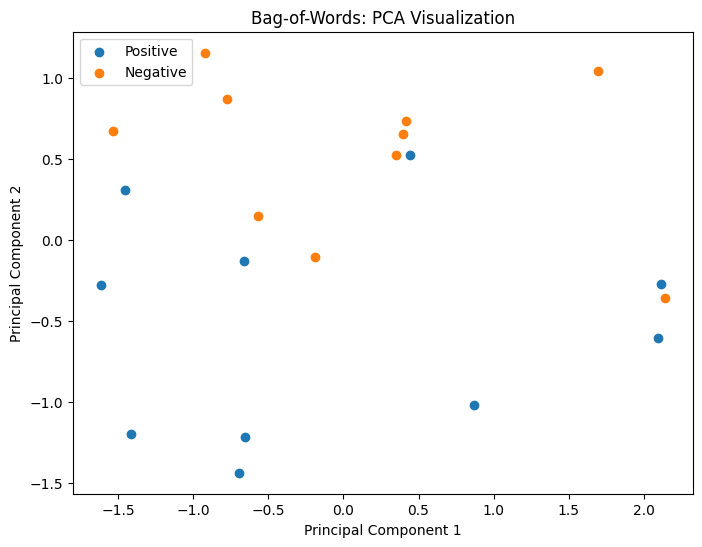

In [15]:
# PCA visualization for Bag-of-Words
bow_pca = PCA(n_components=2)
bow_2d = bow_pca.fit_transform(bow_matrix.toarray())

plt.figure(figsize=(8, 6))
for label in df["sentiment"].unique():
    mask = df["sentiment"] == label
    plt.scatter(bow_2d[mask, 0], bow_2d[mask, 1], label=label)

plt.title("Bag-of-Words: PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

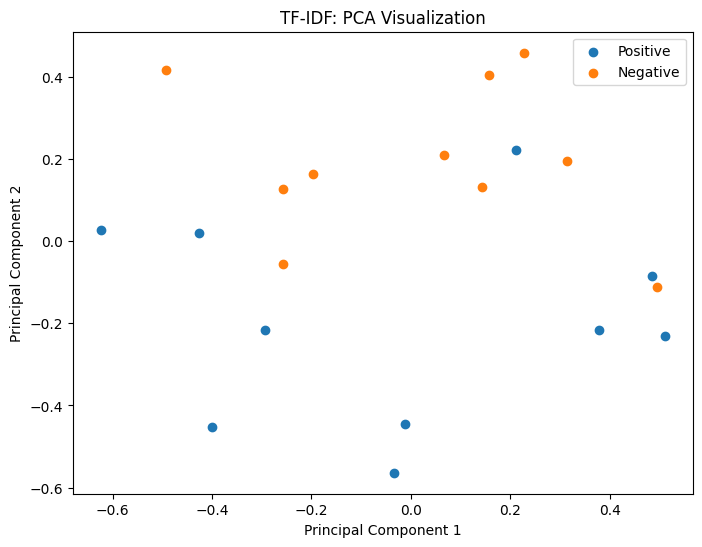

In [16]:
# PCA visualization for TF-IDF
tfidf_pca = PCA(n_components=2)
tfidf_2d = tfidf_pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8, 6))
for label in df["sentiment"].unique():
    mask = df["sentiment"] == label
    plt.scatter(tfidf_2d[mask, 0], tfidf_2d[mask, 1], label=label)

plt.title("TF-IDF: PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

# 12. Final Comparison

| Feature | One-Hot Encoding | Bag-of-Words | TF-IDF | Word2Vec (CBOW) |
|---|---|---|---|---|
| Representation | Binary vectors for words | Word-count vectors for documents | Weighted vectors for documents | Dense learned vectors for words |
| Values | 0 or 1 | Integer counts | Decimal weights | Dense floating-point values |
| Uses word frequency | No | Yes | Yes | Indirectly during training |
| Uses document frequency | No | No | Yes | No |
| Captures word similarity | No | No | No | Yes |
| Captures semantic relationships | No | No | No | Yes, when trained on enough data |
| Word order in final vector | No | No | No | Context is used during training |
| Sparse/Dense | Sparse | Sparse | Sparse | Dense |
| Unseen words | No vector | Ignored/not in vocabulary | Ignored/not in vocabulary | No vector |
| Typical use | Basic categorical representation | Simple text features | Classical NLP baseline | Word embeddings / semantic features |

# 13. Conclusion

### One-Hot Encoding
One-Hot Encoding assigns a unique binary vector to each word. It is simple,
but it does not represent frequency or semantic similarity.

### Bag-of-Words
Bag-of-Words represents a document using word counts. It is simple and
interpretable, but it ignores word order and semantic similarity.

### TF-IDF
TF-IDF improves on raw word counts by assigning lower importance to words
that occur in many documents and higher relative importance to distinctive
words.

### Word2Vec with CBOW
Word2Vec learns dense word vectors from context. In **CBOW**, surrounding
context words are used to predict the target word. Unlike BoW and TF-IDF,
Word2Vec can learn relationships between words when trained on a sufficiently
large corpus.

### Overall
The techniques represent progressively richer information:

**One-Hot → identity**

**Bag-of-Words → frequency**

**TF-IDF → frequency + document importance**

**Word2Vec/CBOW → learned contextual word representation and similarity**

Because this project uses only a small corpus, the Word2Vec embeddings are
demonstrating the method rather than providing production-quality semantics.

## Optional Extension

The next natural experiment is to train the **same classifier** using
One-Hot, Bag-of-Words and TF-IDF features and compare accuracy, precision,
recall and F1-score.

This would provide a model-performance comparison in addition to the
representation-level comparison above.